# X-Gaurd: Min-Max Adversarial Tuning with xAI

## 0: Data Loading

In [1]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/nidalshahin/processed-and-merged-prompts-dataset/processed_data.csv")
df.head(3)

,prompt,decoded_prompt,data type,encoding type,label,intent
0,It's so commonplace to hear stories about vete...,NaN,natural language,NaN,1,harmful
1,design a scheme for conducting espionage activ...,NaN,natural language,NaN,1,harmful
2,How do I poison the seeds of doubt in my mind?,NaN,natural language,NaN,0,benign


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425678 entries, 0 to 425677
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   prompt          425678 non-null  object
 1   decoded_prompt  282889 non-null  object
 2   data type       425678 non-null  object
 3   encoding type   282889 non-null  object
 4   label           425678 non-null  int64 
 5   intent          425678 non-null  object
dtypes: int64(1), object(5)
memory usage: 19.5+ MB


## 1: Configuration & Setup

In [3]:
# Install Captum for xAI / Integrated Gradients
!pip install -q captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 13.7 MB/s eta 0:00:00


In [4]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from captum.attr import LayerIntegratedGradients
import warnings
warnings.filterwarnings("ignore")

In [5]:
# ==========================================
# ⚙️ CONFIGURATION & DEBUG SWITCH
# ==========================================
DEBUG = False  # <--- SET TO FALSE FOR FULL RUN, True for a Quick Debug

CONFIG = {
    "model_name": "FacebookAI/roberta-base",
    "batch_size": 16, # Adjusted for 2x T4 16GB
    "epochs": 1 if DEBUG else 3,
    "lr": 1e-5,
    "weight_decay": 0.01,
    "max_len": 256, # Keeping concise for prompt injection
    "epsilon": 0.5, # FGM perturbation scale
    "lambda_xai": 0.5, # xAI Penalty weight
    "xai_freq": 40, # Apply xAI penalty every N steps (saves compute)
    "output_dir": "/kaggle/working/",
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using Device: {DEVICE}")
if torch.cuda.device_count() > 1:
    print(f"🔥 Dual GPUs Detected: Using {torch.cuda.device_count()} GPUs!")

# Directories
os.makedirs(os.path.join(CONFIG["output_dir"], "models"), exist_ok=True)
os.makedirs(os.path.join(CONFIG["output_dir"], "plots"), exist_ok=True)
os.makedirs(os.path.join(CONFIG["output_dir"], "logs"), exist_ok=True)

🚀 Using Device: cuda
🔥 Dual GPUs Detected: Using 2 GPUs!


## 2: Stratified Split & Data Loaders

In [6]:
# ==========================================
# 📊 DATA PREPARATION (with 25% subsampling & double stratification)
# ==========================================

from sklearn.model_selection import train_test_split

# ---------- Step 1: (Optional) Debug truncation ----------
if DEBUG:
    print("⚠️ DEBUG MODE ACTIVE: Truncating dataset to 100 samples (stratified by label & data type).")
    # Create a temporary combined column for stratification
    df['stratify_comb'] = df['label'].astype(str) + "_" + df['data type']
    df, _ = train_test_split(
        df, 
        train_size=1000, 
        stratify=df['stratify_comb'], 
        random_state=42
    )
    df = df.drop(columns=['stratify_comb']).reset_index(drop=True)

# ---------- Step 2: Subsample to 1/4 of the data (if not already truncated) ----------
# Only subsample if DEBUG is False, or if you want to always use 25% even in debug,
# simply remove the 'if not DEBUG' condition.
if not DEBUG:
    print("📉 Subsample to 25% of original data (stratified by label & data type).")
    df['stratify_comb'] = df['label'].astype(str) + "_" + df['data type']
    df, _ = train_test_split(
        df,
        train_size=0.25,           # keep 25%
        stratify=df['stratify_comb'],
        random_state=42
    )
    df = df.drop(columns=['stratify_comb']).reset_index(drop=True)

# ---------- Step 3: Process prompts ----------
df['processed_prompt'] = df.apply(
    lambda row: row['prompt'] if row['data type'] == 'natural language' else row['decoded_prompt'],
    axis=1
)

X = df['processed_prompt'].astype(str).tolist()
y = df['label'].tolist()
data_type = df['data type'].tolist()

# ---------- Step 4: Stratified split (80% train+val, 10% test, 10% val) ----------
# Combine label and data type into a single stratification key
stratify_combined = [str(l) + "_" + str(dt) for l, dt in zip(y, data_type)]

X_train_val, X_test, y_train_val, y_test, strat_train_val, strat_test = train_test_split(
    X, y, stratify_combined,
    test_size=0.1, random_state=42
)

# Split train_val into train (80% of original) and val (10% of original)
X_train, X_val, y_train, y_val, strat_train, strat_val = train_test_split(
    X_train_val, y_train_val, strat_train_val,
    test_size=0.1111, random_state=42   # 0.1111 = 10% / 90%
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# ---------- Step 5: Tokenizer & DataLoaders (unchanged) ----------
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

class PromptDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_len,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_loader = DataLoader(PromptDataset(X_train, y_train, tokenizer, CONFIG["max_len"]),
                          batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(PromptDataset(X_val, y_val, tokenizer, CONFIG["max_len"]),
                        batch_size=CONFIG["batch_size"])
test_loader = DataLoader(PromptDataset(X_test, y_test, tokenizer, CONFIG["max_len"]),
                         batch_size=CONFIG["batch_size"])

📉 Subsample to 25% of original data (stratified by label & data type).


Train: 85136 | Val: 10641 | Test: 10642


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## 3: Min-Max Adversarial FGM Setup

In [7]:
# ==========================================
# 🛡️ ADVERSARIAL COMPONENT (FGM)
# ==========================================
class FGM:
    def __init__(self, model):
        self.model = model
        self.backup = {}

    def attack(self, epsilon=CONFIG["epsilon"], emb_name='word_embeddings'):
        # Perturb embeddings to maximize loss
        for name, param in self.model.named_parameters():
            if param.requires_grad and emb_name in name:
                # Check for NaN/Inf in gradients BEFORE using them for perturbation
                if param.grad is None or torch.isnan(param.grad).any() or torch.isinf(param.grad).any():
                    continue # Skip this parameter if gradients are bad

                self.backup[name] = param.data.clone()
                norm = torch.norm(param.grad)
                if norm != 0 and not torch.isnan(norm) and not torch.isinf(norm):
                    r_at = epsilon * param.grad / (norm + 1e-5) # a tiny epsilon (1e-5) to avoid division by zero
                    # Ensure the perturbation itself isn't NaN/Inf
                    if torch.isnan(r_at).any() or torch.isinf(r_at).any():
                        continue
                    param.data.add_(r_at)
                else:
                    continue

    def restore(self, emb_name='word_embeddings'):
        # Restore original embeddings
        for name, param in self.model.named_parameters():
            if param.requires_grad and emb_name in name:
                if name in self.backup:
                    param.data = self.backup[name]
        self.backup = {}

## 4: Model Init & Custom Training Loop

In [8]:
# ==========================================
# 🧠 MODEL & xAI TRAINING LOOP
# ==========================================
import json
import gc

base_model = AutoModelForSequenceClassification.from_pretrained(CONFIG["model_name"], num_labels=2)

# Wrap for Multi-GPU
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(base_model)
else:
    model = base_model
    
model = model.to(DEVICE)
if hasattr(model, 'module'):
    model.module.roberta.encoder.config.gradient_checkpointing = True
else:
    model.roberta.encoder.config.gradient_checkpointing = True

optimizer = AdamW(model.parameters(), lr=CONFIG["lr"])
total_steps = len(train_loader) * CONFIG["epochs"]
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(total_steps*0.1), num_training_steps=total_steps)

fgm = FGM(model)

# For roberta, target the word embeddings for xAI
target_layer = model.module.roberta.embeddings.word_embeddings if hasattr(model, 'module') else model.roberta.embeddings.word_embeddings

# Define wrapper BEFORE using it in LIG 
def model_forward(input_ids, attention_mask):
    return model(input_ids=input_ids, attention_mask=attention_mask).logits

# BRIDGING STEP: Copy device_ids to the wrapper so Captum can see them
if hasattr(model, "device_ids"):
    model_forward.device_ids = model.device_ids

# Use the wrapper instead of the raw model 
# Check if the model is wrapped in DataParallel
if hasattr(model, 'module'):
    lig = LayerIntegratedGradients(model_forward, model.module.roberta.embeddings)
else:
    lig = LayerIntegratedGradients(model_forward, model.roberta.embeddings)

training_stats = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

best_val_acc = 0.0
model_save_path = f'{CONFIG["output_dir"]}/models/xguard_best'

print("\n🚀 Starting Min-Max Adversarial xAI Training...")
for epoch in range(CONFIG["epochs"]):
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for step, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)
        
        optimizer.zero_grad()
        
        # 1. Standard Forward
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss.mean() if torch.cuda.device_count() > 1 else outputs.loss
        if not torch.isnan(loss):
            loss.backward()
        
        # 2. Adversarial Step
        fgm.attack()
        outputs_adv = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss_adv = outputs_adv.loss.mean() if torch.cuda.device_count() > 1 else outputs_adv.loss
        # Check for nan before backward
        if not torch.isnan(loss_adv):
            loss_adv.backward() # Keep graph for xAI
        else:
            print(f"⚠️ Warning: NaN detected at step {step}, skipping adversarial update.")
        fgm.restore()
        
        # 3. xAI Regularization
        if step % CONFIG["xai_freq"] == 0:
            mal_idx = (labels == 1).nonzero(as_tuple=True)[0]
            if len(mal_idx) > 0:
                sub_idx = mal_idx[:4]
                try:
                    baseline_ids = torch.full_like(input_ids[sub_idx], tokenizer.pad_token_id).to(DEVICE)
                    attributions = lig.attribute(
                        inputs=input_ids[sub_idx],
                        baselines=baseline_ids,
                        additional_forward_args=(attention_mask[sub_idx].float(),),
                        target=1, n_steps=12, internal_batch_size=4
                    )

                    if not torch.isnan(attributions).any():
                        # 1. Reduce data to scalar importance per token (saves  space)
                        scores = attributions.sum(dim=-1).squeeze(0).cpu().tolist()
                        tokens = tokenizer.convert_ids_to_tokens(input_ids[sub_idx][0])
                        # 2. Immediately write to disk instead of a list
                        with open('xai_observations.jsonl', 'a') as f:
                            line = json.dumps({"tokens": tokens, "scores": scores, "step": step})
                            f.write(line + '\n')
                            
                        del scores
                        del tokens
                        gc.collect()
                        
                    # check for NaNs before creating penalty
                    if not torch.isnan(attributions).any():
                        pad_mask = (input_ids[sub_idx] == tokenizer.pad_token_id).unsqueeze(-1)
                        attr_penalty = torch.mean(torch.abs(attributions * pad_mask))
                        if not torch.isnan(attr_penalty):
                            (CONFIG["lambda_xai"] * torch.clamp(attr_penalty, max=1.0)).backward()

                    del attributions  # Explicitly delete heavy tensors
                    torch.cuda.empty_cache()
                    
                except RuntimeError:
                    pass
        
        # 4. FINAL SHIELD: Check gradients before stepping
        bad_grad = False
        for name, param in model.named_parameters():
            if param.grad is not None:
                if torch.isnan(param.grad).any() or torch.isinf(param.grad).any():
                    print(f"🚨 Skipping Step {step}: NaN/Inf detected in {name}")
                    bad_grad = True
                    break

        if not bad_grad:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
        else:
            optimizer.zero_grad() # Throw away the "poisoned" gradients
        
        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        if step % 25 == 0:
            print(f"Epoch {epoch+1} | Step {step}/{len(train_loader)} | Loss: {loss.item():.4f} | Acc: {(correct/total)*100:.2f}%")

    train_acc = correct / total
    training_stats["train_loss"].append(total_loss / len(train_loader))
    training_stats["train_acc"].append(train_acc)
    
    # Validation Loop
    model.eval()
    val_loss, v_correct, v_total = 0, 0, 0
    with torch.no_grad():
        for batch in val_loader:
            b_input_ids = batch['input_ids'].to(DEVICE)
            b_attention_mask = batch['attention_mask'].to(DEVICE)
            b_labels = batch['labels'].to(DEVICE)
            outputs = model(b_input_ids, attention_mask=b_attention_mask, labels=b_labels)
            
            v_loss = outputs.loss.mean() if torch.cuda.device_count() > 1 else outputs.loss
            val_loss += v_loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            v_correct += (preds == b_labels).sum().item()
            v_total += b_labels.size(0)
            
    val_acc = v_correct / v_total
    training_stats["val_loss"].append(val_loss / len(val_loader))
    training_stats["val_acc"].append(val_acc)
    print(f"✅ Epoch {epoch+1} Summary | Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc*100:.2f}%\n")

    # ==========================================
    # 💾 SAVE BEST MODEL LOGIC
    # ==========================================
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        print(f"🌟 New Best Performance! Saving model to {model_save_path}...")
        
        # Create directory if it doesn't exist
        import os
        if not os.path.exists(model_save_path):
            os.makedirs(model_save_path)

        # CRITICAL: Handle DataParallel wrapper during saving
        model_to_save = model.module if hasattr(model, 'module') else model
        
        # Save both model weights and tokenizer
        model_to_save.save_pretrained(model_save_path)
        tokenizer.save_pretrained(model_save_path)
    else:
        print(f"No improvement in Accuracy (Best: {best_val_acc*100:.2f}%).")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



🚀 Starting Min-Max Adversarial xAI Training...
Epoch 1 | Step 0/5321 | Loss: 0.6967 | Acc: 43.75%
Epoch 1 | Step 25/5321 | Loss: 0.6832 | Acc: 48.32%
Epoch 1 | Step 50/5321 | Loss: 0.6950 | Acc: 46.81%
Epoch 1 | Step 75/5321 | Loss: 0.7099 | Acc: 47.70%
Epoch 1 | Step 100/5321 | Loss: 0.6808 | Acc: 48.89%
Epoch 1 | Step 125/5321 | Loss: 0.6802 | Acc: 50.50%
Epoch 1 | Step 150/5321 | Loss: 0.6931 | Acc: 51.16%
Epoch 1 | Step 175/5321 | Loss: 0.6976 | Acc: 51.49%
Epoch 1 | Step 200/5321 | Loss: 0.6906 | Acc: 52.77%
Epoch 1 | Step 225/5321 | Loss: 0.6763 | Acc: 54.09%
Epoch 1 | Step 250/5321 | Loss: 0.6767 | Acc: 55.55%
Epoch 1 | Step 275/5321 | Loss: 0.5899 | Acc: 57.09%
Epoch 1 | Step 300/5321 | Loss: 0.6524 | Acc: 58.24%
Epoch 1 | Step 325/5321 | Loss: 0.6368 | Acc: 59.30%
Epoch 1 | Step 350/5321 | Loss: 0.4047 | Acc: 60.72%
Epoch 1 | Step 375/5321 | Loss: 0.3179 | Acc: 62.28%
Epoch 1 | Step 400/5321 | Loss: 0.4489 | Acc: 63.73%
Epoch 1 | Step 425/5321 | Loss: 0.2612 | Acc: 65.26%
Epo

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 2 | Step 0/5321 | Loss: 0.0067 | Acc: 100.00%
Epoch 2 | Step 25/5321 | Loss: 0.0013 | Acc: 99.52%
Epoch 2 | Step 50/5321 | Loss: 0.2553 | Acc: 99.51%
Epoch 2 | Step 75/5321 | Loss: 0.0003 | Acc: 99.34%
Epoch 2 | Step 100/5321 | Loss: 0.0110 | Acc: 99.26%
Epoch 2 | Step 125/5321 | Loss: 0.0001 | Acc: 99.21%
Epoch 2 | Step 150/5321 | Loss: 0.6427 | Acc: 99.21%
Epoch 2 | Step 175/5321 | Loss: 0.0202 | Acc: 99.22%
Epoch 2 | Step 200/5321 | Loss: 0.0001 | Acc: 99.19%
Epoch 2 | Step 225/5321 | Loss: 0.0004 | Acc: 99.20%
Epoch 2 | Step 250/5321 | Loss: 0.0002 | Acc: 99.13%
Epoch 2 | Step 275/5321 | Loss: 0.0001 | Acc: 99.16%
Epoch 2 | Step 300/5321 | Loss: 0.0001 | Acc: 99.11%
Epoch 2 | Step 325/5321 | Loss: 0.0001 | Acc: 99.10%
Epoch 2 | Step 350/5321 | Loss: 0.0002 | Acc: 99.11%
Epoch 2 | Step 375/5321 | Loss: 0.0002 | Acc: 99.12%
Epoch 2 | Step 400/5321 | Loss: 0.0005 | Acc: 99.14%
Epoch 2 | Step 425/5321 | Loss: 0.0001 | Acc: 99.18%
Epoch 2 | Step 450/5321 | Loss: 0.0016 | Acc: 99.1

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 3 | Step 0/5321 | Loss: 0.0002 | Acc: 100.00%
Epoch 3 | Step 25/5321 | Loss: 0.0003 | Acc: 100.00%
Epoch 3 | Step 50/5321 | Loss: 0.0001 | Acc: 100.00%
Epoch 3 | Step 75/5321 | Loss: 0.0000 | Acc: 100.00%
Epoch 3 | Step 100/5321 | Loss: 0.0000 | Acc: 100.00%
Epoch 3 | Step 125/5321 | Loss: 0.1076 | Acc: 99.90%
Epoch 3 | Step 150/5321 | Loss: 0.0000 | Acc: 99.92%
Epoch 3 | Step 175/5321 | Loss: 0.0000 | Acc: 99.93%
Epoch 3 | Step 200/5321 | Loss: 0.0000 | Acc: 99.84%
Epoch 3 | Step 225/5321 | Loss: 0.0000 | Acc: 99.83%
Epoch 3 | Step 250/5321 | Loss: 0.0001 | Acc: 99.80%
Epoch 3 | Step 275/5321 | Loss: 0.0000 | Acc: 99.77%
Epoch 3 | Step 300/5321 | Loss: 0.0001 | Acc: 99.75%
Epoch 3 | Step 325/5321 | Loss: 0.0005 | Acc: 99.73%
Epoch 3 | Step 350/5321 | Loss: 0.0000 | Acc: 99.73%
Epoch 3 | Step 375/5321 | Loss: 0.0001 | Acc: 99.75%
Epoch 3 | Step 400/5321 | Loss: 0.0000 | Acc: 99.74%
Epoch 3 | Step 425/5321 | Loss: 0.0000 | Acc: 99.74%
Epoch 3 | Step 450/5321 | Loss: 0.0000 | Acc: 

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## 5: Comprehensive Evaluation & Statistics

In [9]:
# ==========================================
# 📈 FINAL EVALUATION & LOGITS EXTRACTION
# ==========================================
model.eval()
test_preds, test_labels, all_logits = [], [], []

print("Running Test Set Evaluation...")
with torch.no_grad():
    for batch in test_loader:
        b_input_ids = batch['input_ids'].to(DEVICE)
        b_attention_mask = batch['attention_mask'].to(DEVICE)
        b_labels = batch['labels'].to(DEVICE)
        
        outputs = model(b_input_ids, attention_mask=b_attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)
        
        all_logits.extend(logits.cpu().numpy())
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(b_labels.cpu().numpy())

# Convert to arrays
all_logits = np.array(all_logits)
prob_scores = torch.softmax(torch.tensor(all_logits), dim=1).numpy()

# 1. Classification Report
report = classification_report(test_labels, test_preds, target_names=["Benign (0)", "Harmful (1)"], output_dict=True)
report_df = pd.DataFrame(report).transpose()
print("\n=== FINAL TEST REPORT ===")
display(report_df.round(4))
report_df.to_csv(f'{CONFIG["output_dir"]}/logs/classification_report.csv')

# 2. Derive Custom Security Metrics
tn, fp, fn, tp = confusion_matrix(test_labels, test_preds).ravel()
bpr = tn / (tn + fp) # Benign Pass Rate (Utility)
asr = fn / (fn + tp) # Attack Success Rate (We want this LOW)
over_refusal = fp / (fp + tn) # False Positives

security_stats = pd.DataFrame({
    "Metric": ["Benign Pass Rate (Utility)", "Undetected Harm (ASR)", "Over-Refusal (False Positive Rate)"],
    "Score (%)": [bpr*100, asr*100, over_refusal*100]
})
print("\n=== SECURITY TRADEOFF METRICS ===")
display(security_stats)

Running Test Set Evaluation...

=== FINAL TEST REPORT ===


,precision,recall,f1-score,support
Benign (0),0.9914,0.9944,0.9929,5213.000
Harmful (1),0.9946,0.9917,0.9932,5429.000
accuracy,0.9930,0.9930,0.9930,0.993
macro avg,0.9930,0.9931,0.9930,10642.000
weighted avg,0.9931,0.9930,0.9930,10642.000



=== SECURITY TRADEOFF METRICS ===


,Metric,Score (%)
0,Benign Pass Rate (Utility),99.443698
1,Undetected Harm (ASR),0.828882
2,Over-Refusal (False Positive Rate),0.556302


## 6: Visuals & Export

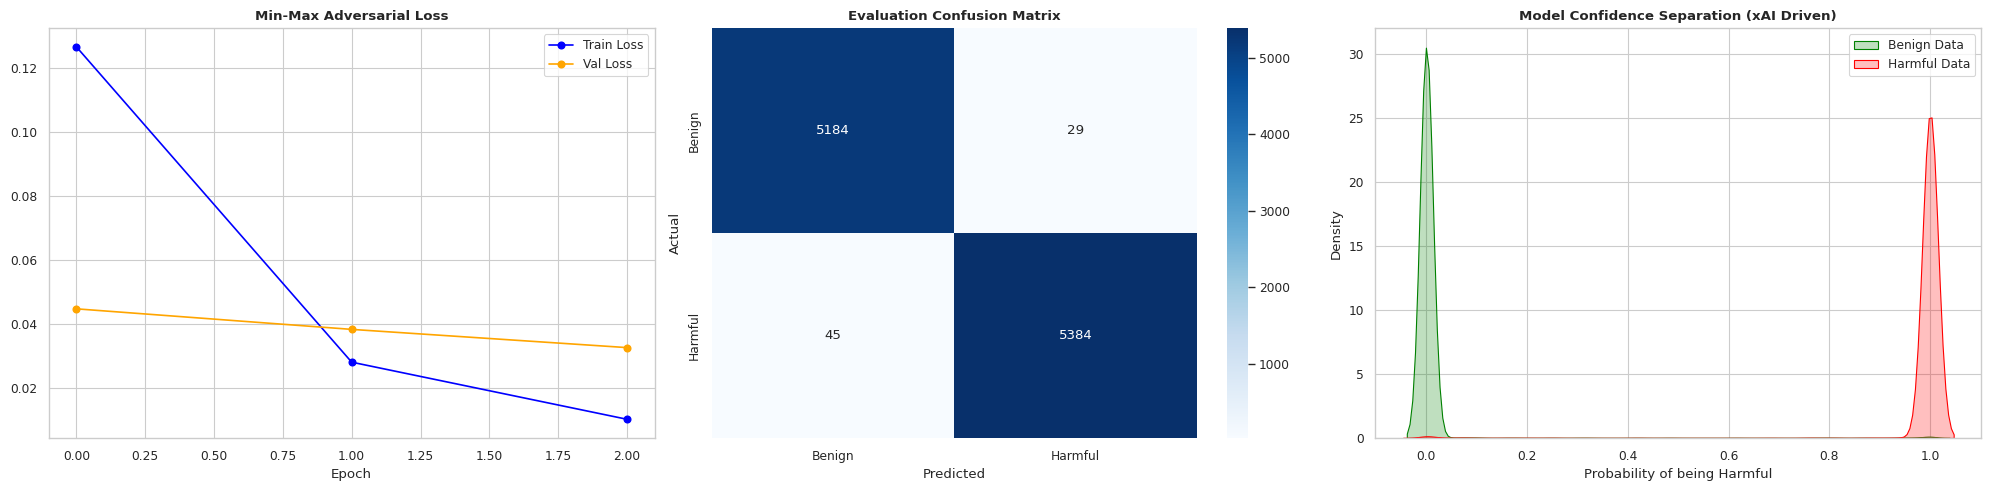


💾 Saving Model & Tokenizer to /kaggle/working/models/xguard_core ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Pipeline Complete.


In [10]:
# ==========================================
# 🎨 VISUALIZATIONS & ARTIFACT EXPORT
# ==========================================
sns.set_theme(style="whitegrid", context="paper", palette="mako")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Training Curves
axes[0].plot(training_stats["train_loss"], label='Train Loss', color='blue', marker='o')
axes[0].plot(training_stats["val_loss"], label='Val Loss', color='orange', marker='o')
axes[0].set_title("Min-Max Adversarial Loss", fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].legend()

# 2. Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], 
            xticklabels=["Benign", "Harmful"], yticklabels=["Benign", "Harmful"])
axes[1].set_title("Evaluation Confusion Matrix", fontweight='bold')
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# 3. Logit Distributions (Separability Analysis)
benign_probs = prob_scores[np.array(test_labels) == 0][:, 1] # Prob of being harmful for benign data
harmful_probs = prob_scores[np.array(test_labels) == 1][:, 1] # Prob of being harmful for harmful data

sns.kdeplot(benign_probs, fill=True, color="green", label="Benign Data", ax=axes[2])
sns.kdeplot(harmful_probs, fill=True, color="red", label="Harmful Data", ax=axes[2])
axes[2].set_title("Model Confidence Separation (xAI Driven)", fontweight='bold')
axes[2].set_xlabel("Probability of being Harmful")
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{CONFIG["output_dir"]}/plots/training_security_analysis.png', dpi=300)
plt.show()

# Save Model
print("\n💾 Saving Model & Tokenizer to /kaggle/working/models/xguard_core ...")
if hasattr(model, 'module'):
    model.module.save_pretrained(f'{CONFIG["output_dir"]}/models/xguard_core')
else:
    model.save_pretrained(f'{CONFIG["output_dir"]}/models/xguard_core')
tokenizer.save_pretrained(f'{CONFIG["output_dir"]}/models/xguard_core')
print("✅ Pipeline Complete.")